# 1) 데이터 읽기

In [11]:
# read file
import pandas as pd

file_path = r'C:\Users\황주신\Documents\University\3학년\1학기\01. 인공지능개론\03. 실습, 과제\W10\abalone\abalone.data'

index = ['Sex', 'Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight', 'Viscera weight', 'Shell weight', 'Rings']

data = pd.read_csv(file_path, header = None)
df = pd.DataFrame(data)

df.columns = index

df

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


# 2) 결측치 확인

In [12]:
# 결측치 확인
df.isnull().sum()

# df = df.dropna()

Sex               0
Length            0
Diameter          0
Height            0
Whole weight      0
Shucked weight    0
Viscera weight    0
Shell weight      0
Rings             0
dtype: int64

# 3) 클래스 갯수 확인 (그래프, 레이블 갯수)

Text(0.5, 1.0, 'Label')

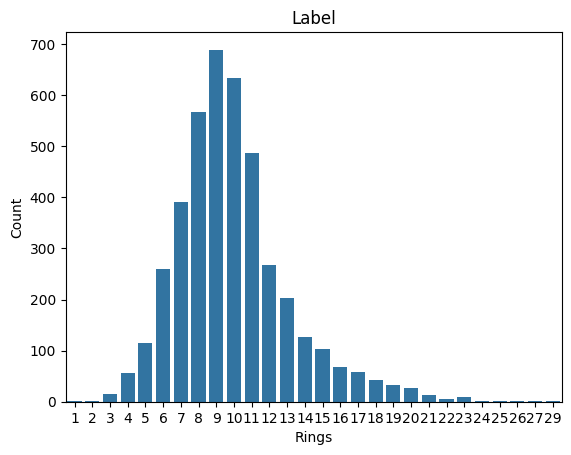

In [13]:
# 레이블 갯수 확인 (그래프)
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data = df, x="Rings")
plt.xlabel("Rings")
plt.ylabel("Count")
plt.title("Label")

In [14]:
# 레이블 갯수 확인 (숫자)
df['Rings'].value_counts()

Rings
9     689
10    634
8     568
11    487
7     391
12    267
6     259
13    203
14    126
5     115
15    103
16     67
17     58
4      57
18     42
19     32
20     26
3      15
21     14
23      9
22      6
27      2
24      2
1       1
26      1
29      1
2       1
25      1
Name: count, dtype: int64

# 4) Label 인코딩

In [15]:
# module import

from sklearn.preprocessing import LabelEncoder

# 라벨 인코딩 함수
def label_encode(data, column):
    label_encoder = LabelEncoder()
    data[column] = label_encoder.fit_transform(data[column])
    return data

# 데이터(data)와 인코딩할 열(column)을 전달하여 label encoding 수행
data = label_encode(data, 0)
# data = label_encode(data, '')

print(data)

# 인코딩된 열을 DataFrame에 추가
df['Sex(encoded)'] = data[0]

# 인코딩 되지 않은 열을 DataFrame에서 삭제
df = df.drop('Sex', axis = 1)

df


      0      1      2      3       4       5       6       7   8
0     2  0.455  0.365  0.095  0.5140  0.2245  0.1010  0.1500  15
1     2  0.350  0.265  0.090  0.2255  0.0995  0.0485  0.0700   7
2     0  0.530  0.420  0.135  0.6770  0.2565  0.1415  0.2100   9
3     2  0.440  0.365  0.125  0.5160  0.2155  0.1140  0.1550  10
4     1  0.330  0.255  0.080  0.2050  0.0895  0.0395  0.0550   7
...  ..    ...    ...    ...     ...     ...     ...     ...  ..
4172  0  0.565  0.450  0.165  0.8870  0.3700  0.2390  0.2490  11
4173  2  0.590  0.440  0.135  0.9660  0.4390  0.2145  0.2605  10
4174  2  0.600  0.475  0.205  1.1760  0.5255  0.2875  0.3080   9
4175  0  0.625  0.485  0.150  1.0945  0.5310  0.2610  0.2960  10
4176  2  0.710  0.555  0.195  1.9485  0.9455  0.3765  0.4950  12

[4177 rows x 9 columns]


,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,Sex(encoded)
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15,2
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7,2
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9,0
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10,2
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7,1
...,...,...,...,...,...,...,...,...,...
4172,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11,0
4173,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10,2
4174,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9,2
4175,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10,0


In [16]:
# str형 데이터가 섞여있는 경우

# # doors에 5more을 5로 변경하기
# df_encoded['Doors'] = df_encoded['Doors'].replace('5more', 5)

# # persons에 more을 6으로 변경하기
# df_encoded['Persons'] = df_encoded['Persons'].replace('more', 6)

# 5) X, Y 나누기

In [17]:
X = df.drop('Rings', axis = 1)
Y = df['Rings']

print(X.head())
print()
print(Y.value_counts())

   Length  Diameter  Height  Whole weight  Shucked weight  Viscera weight  \
0   0.455     0.365   0.095        0.5140          0.2245          0.1010   
1   0.350     0.265   0.090        0.2255          0.0995          0.0485   
2   0.530     0.420   0.135        0.6770          0.2565          0.1415   
3   0.440     0.365   0.125        0.5160          0.2155          0.1140   
4   0.330     0.255   0.080        0.2050          0.0895          0.0395   

   Shell weight  Sex(encoded)  
0         0.150             2  
1         0.070             2  
2         0.210             0  
3         0.155             2  
4         0.055             1  

Rings
9     689
10    634
8     568
11    487
7     391
12    267
6     259
13    203
14    126
5     115
15    103
16     67
17     58
4      57
18     42
19     32
20     26
3      15
21     14
23      9
22      6
27      2
24      2
1       1
26      1
29      1
2       1
25      1
Name: count, dtype: int64


# 6) 데이터 스케일링

In [18]:
from sklearn.preprocessing import StandardScaler
# from sklearn.preprocessing import MinMaxScaler


scaler = StandardScaler()
X_scaled_data = scaler.fit_transform(X)

X = pd.DataFrame(X_scaled_data,
                            index = X.index,
                            columns = X.columns) 

X

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Sex(encoded)
0,-0.574558,-0.432149,-1.064424,-0.641898,-0.607685,-0.726212,-0.638217,1.151980
1,-1.448986,-1.439929,-1.183978,-1.230277,-1.170910,-1.205221,-1.212987,1.151980
2,0.050033,0.122130,-0.107991,-0.309469,-0.463500,-0.356690,-0.207139,-1.280690
3,-0.699476,-0.432149,-0.347099,-0.637819,-0.648238,-0.607600,-0.602294,1.151980
4,-1.615544,-1.540707,-1.423087,-1.272086,-1.215968,-1.287337,-1.320757,-0.064355
...,...,...,...,...,...,...,...,...
4172,0.341509,0.424464,0.609334,0.118813,0.047908,0.532900,0.073062,-1.280690
4173,0.549706,0.323686,-0.107991,0.279929,0.358808,0.309362,0.155685,1.151980
4174,0.632985,0.676409,1.565767,0.708212,0.748559,0.975413,0.496955,1.151980
4175,0.841182,0.777187,0.250672,0.541998,0.773341,0.733627,0.410739,-1.280690


# 7) One-Hot 인코딩

In [10]:
# 예측 값이 문자열이 아니기 때문에 One-Hot 인코딩을 하지 않는다.

# Y = pd.get_dummies(Y).values

# Y

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

# 8) Train데이터, Test데이터 나누기

In [20]:
# split X_train, Y_train, X_test, Y_test
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 0)

# 9) 딥러닝 모델 정의

In [23]:
#Defining the model (함수형 모델 사용)

from keras import Input
from keras import Model
from keras.layers import Dense
from keras.optimizers import Adam

inputs = Input(shape = (8, ))
layer0 = Dense(6, activation = "relu")(inputs)
layer1 = Dense(4, activation = "relu")(layer0)
layer2 = Dense(2, activation = "relu")(layer1)
prediction = Dense(1)(layer2)

model = Model(inputs = inputs, outputs = prediction)

model.compile(Adam(learning_rate = 0.04), 'mse', metrics = ['mse'])

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            28 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95 (380.00 B)

 Trainable params: 95 (380.00 B)

 Non-trainable params: 0 (0.00 B)

# 10) 학습, 예측

In [25]:
import numpy as np

model_history=model.fit(x=X_train, y=Y_train, epochs=30, batch_size=32,validation_data= (X_test,Y_test))
y_pred = model.predict(X_test)

# 확률에 가장 가까운 정수로 class를 예측
y_pred_class = np.argmax(y_pred,axis=1)

# # y_pred_class one-hot-encoding
# Y_pred_class = pd.get_dummies(y_pred_class).values

Epoch 1/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.4165 - mse: 4.4165 - val_loss: 4.7062 - val_mse: 4.7062
Epoch 2/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.6047 - mse: 4.6047 - val_loss: 4.7190 - val_mse: 4.7190
Epoch 3/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.4236 - mse: 4.4236 - val_loss: 4.7542 - val_mse: 4.7542
Epoch 4/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.6641 - mse: 4.6641 - val_loss: 4.9188 - val_mse: 4.9188
Epoch 5/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.3631 - mse: 4.3631 - val_loss: 4.8187 - val_mse: 4.8187
Epoch 6/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.8834 - mse: 4.8834 - val_loss: 4.5953 - val_mse: 4.5953
Epoch 7/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.5015 - mse: 4.5015 - val_loss: 4.8097 - val_mse: 4.8097
Epoch 8/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.8157 - mse: 4.8157 - val_loss: 5.0821 - val_mse: 5.0821
Epoch 9/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

In [30]:
from sklearn import metrics

# 정확도 계산
scores = metrics.accuracy_score(Y_test, y_pred_class)
print(scores)

model.evaluate(X_test, Y_test)

0.0
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4.3348 - mse: 4.3348 


[4.732950687408447, 4.732950687408447]

# 왜 정확도가 이렇게 낮게 나왔는가?

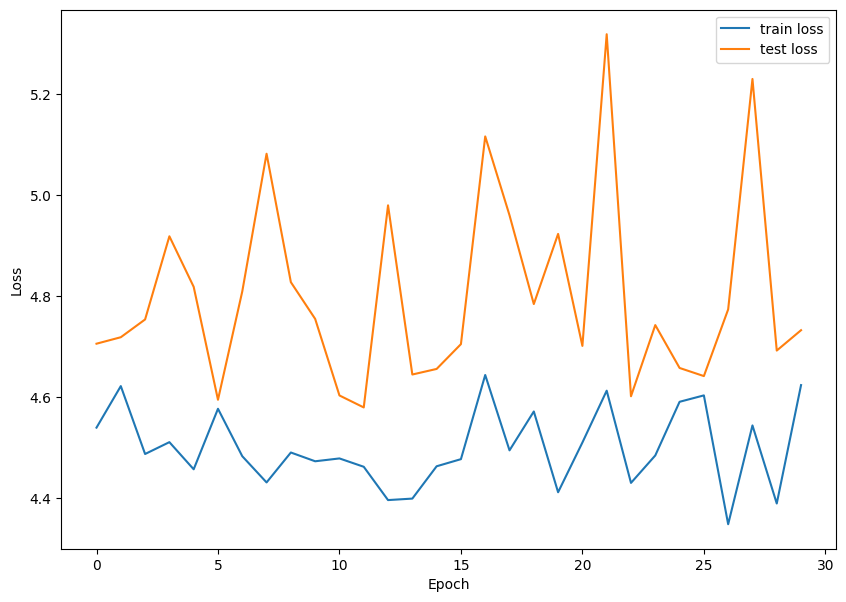

In [33]:
# loss 체크
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))
plt.plot(range(30), model_history.history['loss'], label='train loss')
plt.plot(range(30), model_history.history['val_loss'], label='test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

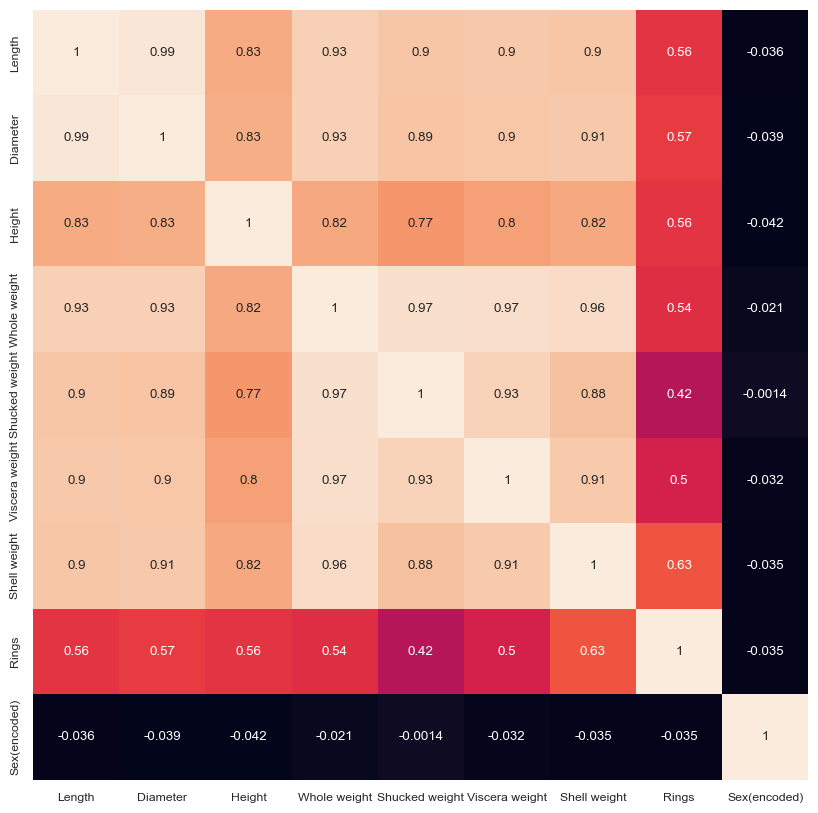

In [34]:
#상관 관계 행렬
# 0.3 이상인 경우 상관관계가 있고, 0.7이상이면 아주 높음
import matplotlib.pyplot as plt
import seaborn as sns

df_corr=df.corr()

#히트맵
plt.figure(figsize=(10,10))
sns.set(font_scale=0.8)
sns.heatmap(df_corr, annot=True, cbar=False)
plt.show()

# PRICE와 높은 건  MedInc

나의 결론 : Rings는 Feature와 큰 상관관계가 없기 때문에, 제대로 예측할 수 없다.